# 📊AtliQ Hotels - Data analysis and Business insights

###  importing libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

###  Loading Dataset

In [3]:
df = pd.read_csv("C:/EDAproject/final_dataset.csv", low_memory=False)
df.head()

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,property_name,category,city,date,mmm yy,week no,day_type
0,May012216558RT12,16558,30-04-22,2022-05-01,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640,Atliq Grands,Luxury,Delhi,NaN,NaN,NaN,NaN
1,May012216558RT15,16558,27-04-22,2022-05-01,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920,Atliq Grands,Luxury,Delhi,NaN,NaN,NaN,NaN
2,May012216558RT16,16558,1/5/2022,2022-05-01,3/5/2022,2.0,RT1,others,4.0,Checked Out,9100,9100,Atliq Grands,Luxury,Delhi,NaN,NaN,NaN,NaN
3,May012216558RT17,16558,28-04-22,2022-05-01,6/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640,Atliq Grands,Luxury,Delhi,NaN,NaN,NaN,NaN
4,May012216558RT18,16558,26-04-22,2022-05-01,3/5/2022,2.0,RT1,logtrip,NaN,No Show,9100,9100,Atliq Grands,Luxury,Delhi,NaN,NaN,NaN,NaN


### 📌 Data Overview

- Total Records: **7.3 Million**
- Total Columns: **19**
- Dataset contains booking, revenue, customer behavior, and property details.

#### Key Columns:
- Booking Details → booking_id, booking_date, check_in_date, checkout_date  
- Customer Info → no_guests, ratings_given  
- Business Metrics → revenue_generated, revenue_realized  
- Segmentation → city, room_category, booking_platform  

> The dataset is large-scale and suitable for analyzing booking trends, revenue patterns, and customer behavior.

### 🧠 Dataset Understanding

This dataset represents booking-level transactions across multiple properties and cities.  
Each row corresponds to a single booking, capturing revenue, platform, and customer behavior.

The data enables analysis of:
- Revenue leakage (cancelled / no-show bookings)
- Platform performance
- Property and city-level trends

## 📊 Insight 1: Booking Status Distribution

Understanding how bookings are distributed across statuses helps identify revenue leakage and operational inefficiencies.

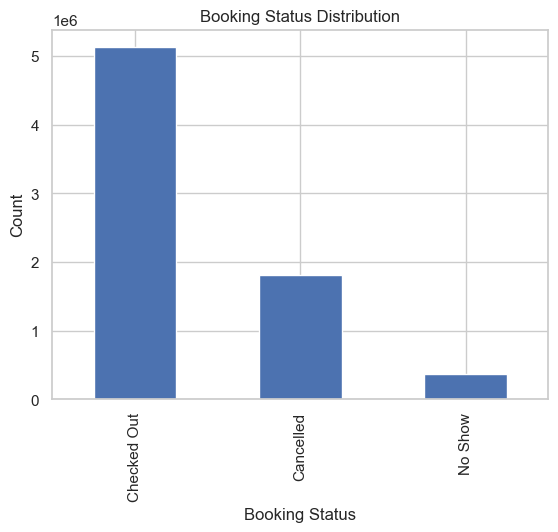

In [7]:
df['booking_status'].value_counts().plot(kind='bar')
plt.title("Booking Status Distribution")
plt.xlabel("Booking Status")
plt.ylabel("Count")
plt.show()

### 🧠 Key Insight:

- Majority of bookings are successfully completed.
- However, a noticeable portion is either **Cancelled** or **No Show**.
- This indicates **potential revenue leakage** and inefficiencies in booking management.

## 📊 Insight 2: Revenue Leakage Analysis

Comparing generated vs realized revenue helps quantify business losses.

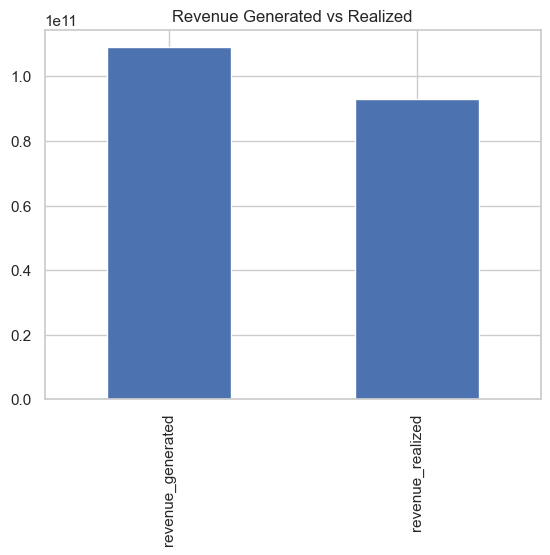

In [8]:
df[['revenue_generated', 'revenue_realized']].sum().plot(kind='bar')
plt.title("Revenue Generated vs Realized")
plt.show()

### 🧠 Key Insight:

- There is a gap between revenue generated and revenue realized.
- This gap is mainly due to **cancellations and no-shows**.
- Reducing these can directly increase profitability.

## 📊 Insight 3: Revenue by Booking Platform

Analyzing which platforms contribute most to revenue.

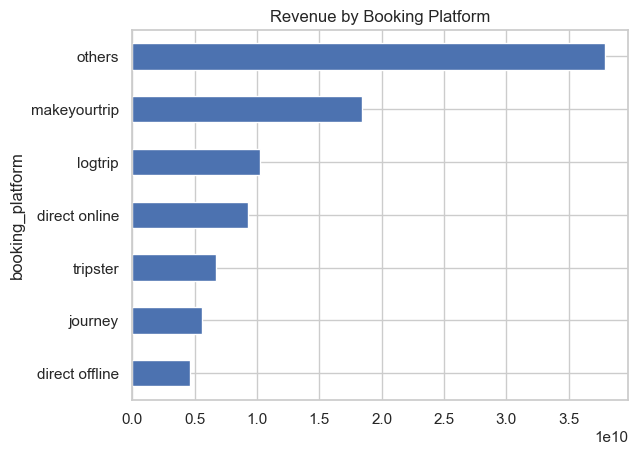

In [9]:
df.groupby('booking_platform')['revenue_realized'].sum().sort_values().plot(kind='barh')
plt.title("Revenue by Booking Platform")
plt.show()

### 🧠 Key Insight:

- Certain platforms dominate revenue contribution.
- Direct bookings vs third-party platforms can be compared for profitability.
- High dependency on few platforms may indicate **risk concentration**.

## 📊 Insight 4: Revenue by City

Understanding which cities drive the most business.

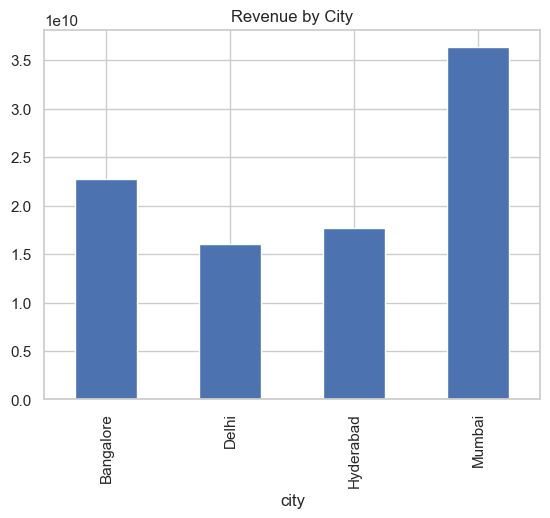

In [10]:
df.groupby('city')['revenue_realized'].sum().plot(kind='bar')
plt.title("Revenue by City")
plt.show()

### 🧠 Key Insight:

- Some cities contribute significantly higher revenue.
- This indicates strong demand and market dominance in those locations.

## 📊 Insight 5: Room Category Analysis

Evaluating which room types generate the most revenue.

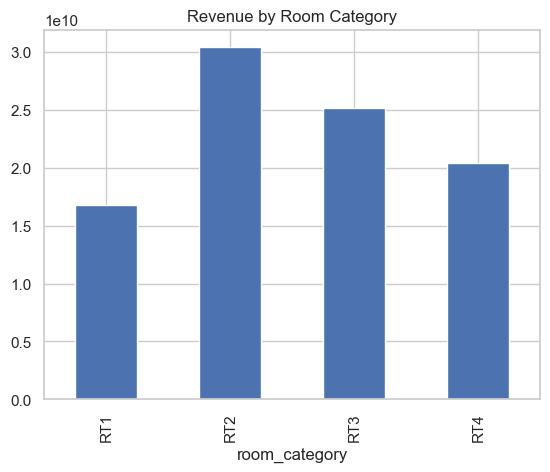

In [15]:
df.groupby('room_category')['revenue_realized'].sum().plot(kind='bar')
plt.title("Revenue by Room Category")
plt.show()

### 🧠 Key Insight:

- Certain room categories outperform others in revenue.
- Helps in pricing strategy and inventory planning.

## 📊 Insight 6: Weekday vs Weekend Revenue

Understanding demand variation across weekdays and weekends.

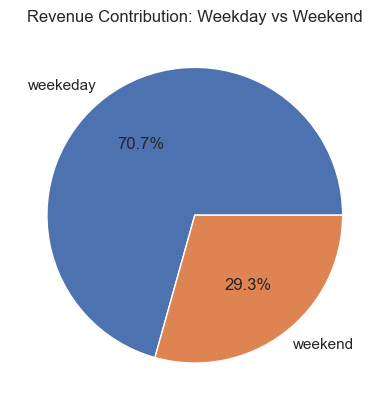

In [16]:
df.groupby('day_type')['revenue_realized'].sum().plot(kind='pie', autopct='%1.1f%%')
plt.title("Revenue Contribution: Weekday vs Weekend")
plt.ylabel('')
plt.show()

### 🧠 Key Insights:

- Weekends contribute a larger share of revenue, indicating strong leisure travel demand.
- Weekdays show relatively lower revenue, likely driven by business travelers.
- This suggests an opportunity to boost weekday revenue through targeted offers or corporate tie-ups.

## 📊 Insight 7: Booking Trend Over Time

Analyzing how booking volume changes over time helps identify seasonality and demand fluctuations.

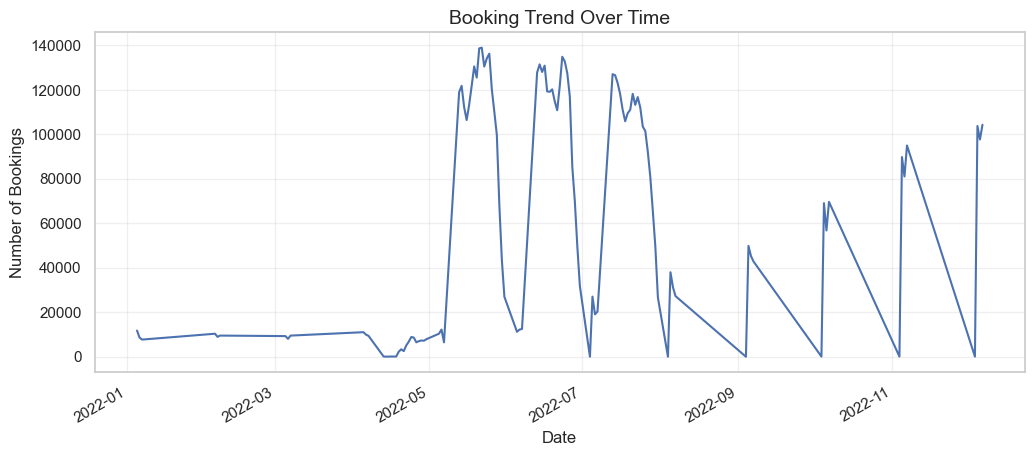

In [25]:
import warnings
warnings.filterwarnings('ignore')
df['booking_date'] = pd.to_datetime(df['booking_date'], errors='coerce')

# Grouping data
booking_trend = df.groupby('booking_date')['booking_id'].count()

# Ploting trend
plt.figure(figsize=(12,5))
booking_trend.plot()

plt.title("Booking Trend Over Time", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Number of Bookings")
plt.grid(alpha=0.3)

plt.show()

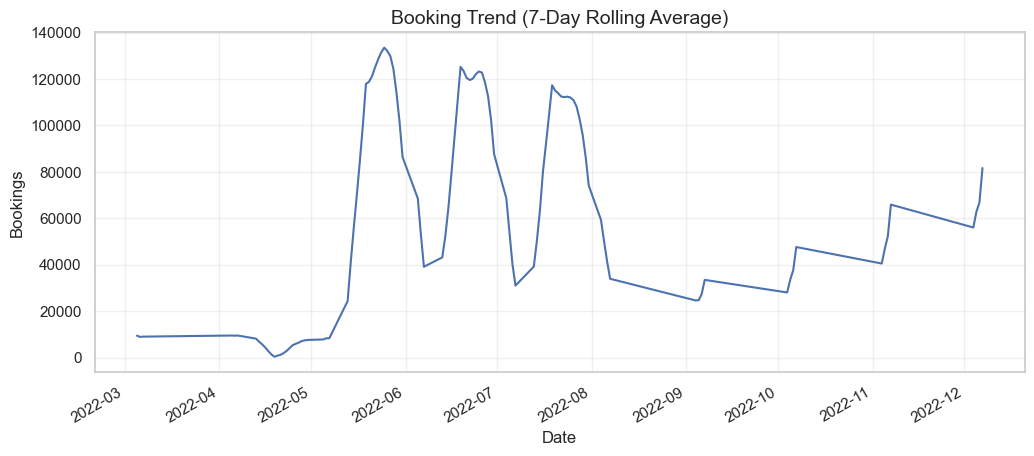

In [18]:
plt.figure(figsize=(12,5))

booking_trend.rolling(7).mean().plot()

plt.title("Booking Trend (7-Day Rolling Average)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Bookings")
plt.grid(alpha=0.3)

plt.show()

### 🧠 Key Insights:

- Booking volumes fluctuate significantly over time, indicating changing demand.
- Peaks represent high-demand periods such as holidays or travel seasons.
- Lower periods indicate off-season demand where marketing efforts can be increased.
- The rolling average reveals the underlying demand trend by smoothing short-term fluctuations.
- This insight is critical for demand forecasting and pricing optimization.

## 📊 Insight 8: Ratings vs Revenue

Understanding how customer ratings impact revenue realization.

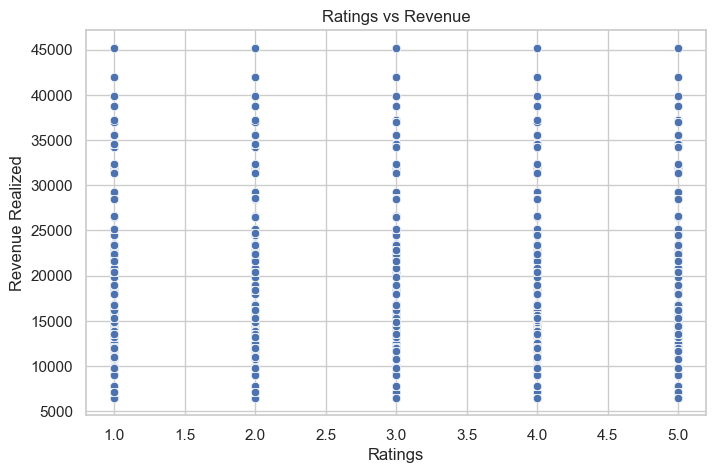

In [20]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='ratings_given',
    y='revenue_realized'
)

plt.title("Ratings vs Revenue")
plt.xlabel("Ratings")
plt.ylabel("Revenue Realized")

plt.show()

### 🧠 Key Insights:

- Higher ratings generally correlate with higher revenue realization.
- Properties with better customer satisfaction tend to perform financially better.
- This highlights the importance of maintaining service quality.
- Improving customer experience can directly increase revenue.

## 📊 Insight 9: Cancellation Analysis

Analyzing booking cancellations to understand revenue loss patterns.

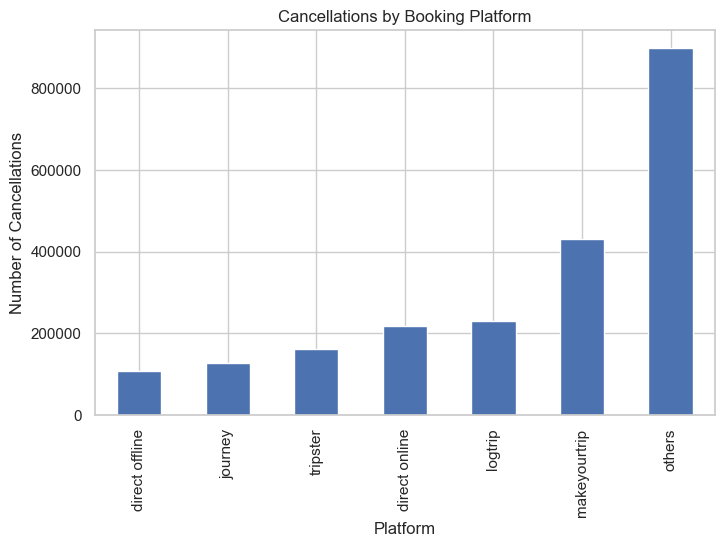

In [22]:
cancel_data = df[df['booking_status'] != 'Checked Out']

plt.figure(figsize=(8,5))

cancel_data.groupby('booking_platform')['booking_id'].count().sort_values().plot(kind='bar')

plt.title("Cancellations by Booking Platform")
plt.xlabel("Platform")
plt.ylabel("Number of Cancellations")

plt.show()

### 🧠 Key Insights:

- Certain platforms have higher cancellation rates.
- This may indicate lower booking commitment or pricing mismatches.
- High cancellations directly contribute to revenue leakage.
- Platforms with high cancellations require better policies or incentives.

## 📊 Insight 10: City vs Platform Revenue Heatmap

Analyzing how different booking platforms perform across cities.

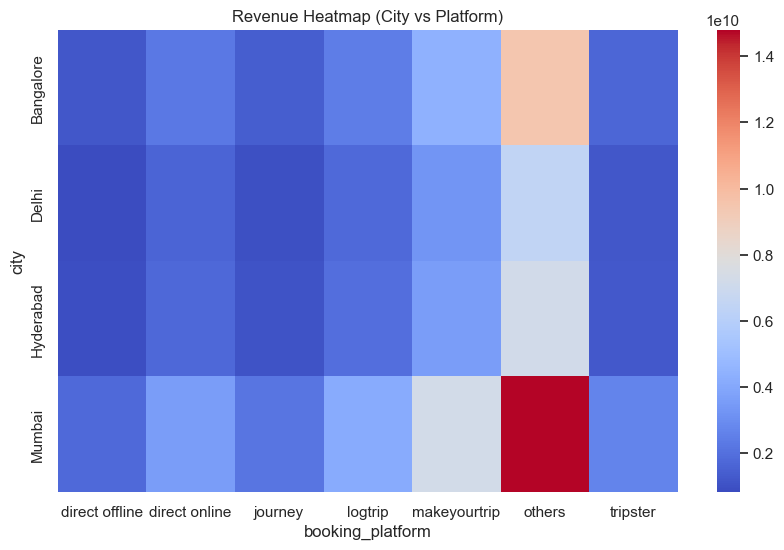

In [23]:
pivot = df.pivot_table(
    values='revenue_realized',
    index='city',
    columns='booking_platform',
    aggfunc='sum'
)

plt.figure(figsize=(10,6))

sns.heatmap(pivot, cmap='coolwarm', annot=False)

plt.title("Revenue Heatmap (City vs Platform)")

plt.show()

### 🧠 Key Insights:

- Different platforms dominate in different cities.
- Some cities rely heavily on specific booking platforms.
- This indicates regional customer behavior differences.
- Helps optimize platform-specific marketing strategies for each city.

## 💼 Business Recommendations

Based on the analysis, the following strategic recommendations can help improve performance and profitability:

### 1. Reduce Revenue Leakage
- High cancellations and no-shows are impacting realized revenue.
- Introduce stricter cancellation policies or partial advance payments.
- Implement reminder notifications to reduce no-shows.

### 2. Optimize Weekday Revenue
- Weekends show higher revenue compared to weekdays.
- Introduce weekday discounts, corporate tie-ups, or business packages.
- Target business travelers to increase weekday occupancy.

### 3. Improve Customer Experience
- Higher ratings are associated with better revenue performance.
- Focus on service quality, cleanliness, and customer satisfaction.
- Encourage reviews and feedback to build trust.

### 4. Platform Strategy Optimization
- Certain booking platforms contribute more revenue than others.
- Strengthen partnerships with high-performing platforms.
- Reduce dependency on platforms with high cancellation rates.

### 5. City-Level Strategy
- Some cities generate significantly higher revenue.
- Invest more in marketing and expansion in high-performing cities.
- Improve performance in low-performing cities through targeted campaigns.

### 6. Demand Forecasting & Pricing
- Booking trends show seasonal demand fluctuations.
- Use dynamic pricing strategies during peak periods.
- Offer promotions during low-demand periods to balance occupancy.

---

## 📌 Conclusion

This analysis provided a comprehensive understanding of booking behavior, revenue patterns, and customer trends across AtliQ Hotels.

Key findings include:
- Significant revenue leakage due to cancellations and no-shows
- Strong dependency on specific booking platforms
- Clear seasonality and demand fluctuations over time
- Higher revenue contribution during weekends
- Positive correlation between customer ratings and revenue

Overall, the insights highlight opportunities to improve revenue realization, optimize platform strategy, and enhance customer experience.

By implementing the recommended strategies, the business can achieve:
- Higher occupancy rates
- Improved revenue efficiency
- Better customer satisfaction
- Stronger market positioning

---

## 🚀 Final Takeaways (Quick Summary)

✨ **Key Highlights from the Analysis:**

- 💸 **Revenue Leakage is Significant**  
  Cancellations and no-shows are directly impacting realized revenue.

- 📅 **Weekend Demand Dominates**  
  Higher bookings on weekends reflect strong leisure travel behavior.

- ⭐ **Customer Experience Drives Revenue**  
  Better ratings are linked with higher revenue realization.

- 🌐 **Booking Platforms Matter**  
  A few platforms contribute the majority of revenue, creating dependency.

- 📈 **Clear Demand Seasonality**  
  Booking trends show fluctuations, enabling forecasting and dynamic pricing.

---

🎯 **Final Thought:**  
Improving cancellation control, enhancing customer experience, and optimizing platform strategy can significantly boost revenue and operational efficiency.